<a href="https://colab.research.google.com/github/gaddam007-git/IIIT-HYD/blob/main/NOTEBOOKS/Copy_of_AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=d867e65ff235f89822ed451eb143e00224dac1a1394d6de49a1fe2e0e2c60928
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
topic1 = 'Giraffe'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

fr1 = wikipedia.page('Girafe').content
fr2 = wikipedia.page('Éléphant').content

This is what the text looks like:

In [ ]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. \nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [ ]:
def cleanup(text):
    text = text.lower()
    text = re.sub('[^a-zàâçéèêëîïôûùüÿñæœ ]+', '', text)
    return text

In [ ]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [ ]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [ ]:
# convert tuple of characters to string
def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st

# convert tuple of tuples to list of strings
def key2string(keys):
    return [tuple2string(i) for i in keys]

# plot histogram
def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)
    zipped_sorted = sorted(combined, key=lambda x: x[0])

    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)
    plt.xticks(rotation=90)
    plt.xlabel("N-grams")
    plt.ylabel("Frequency")

Let us compare the histograms of English pages and French pages. Can you spot a difference?

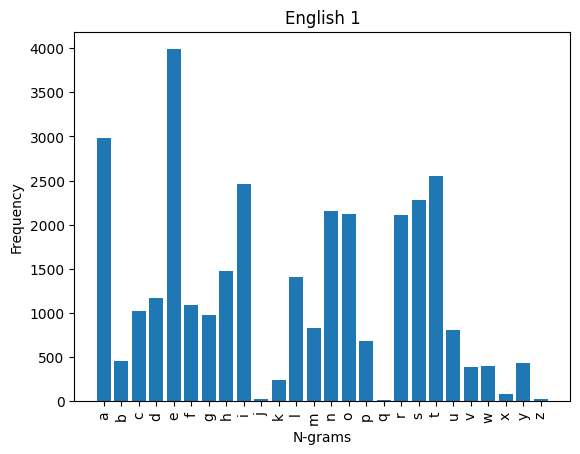

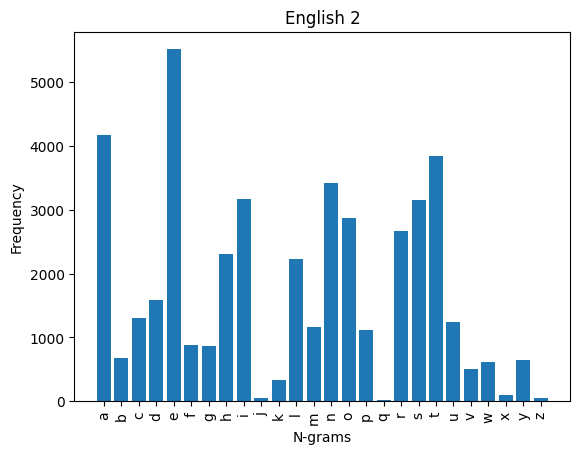

In [ ]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

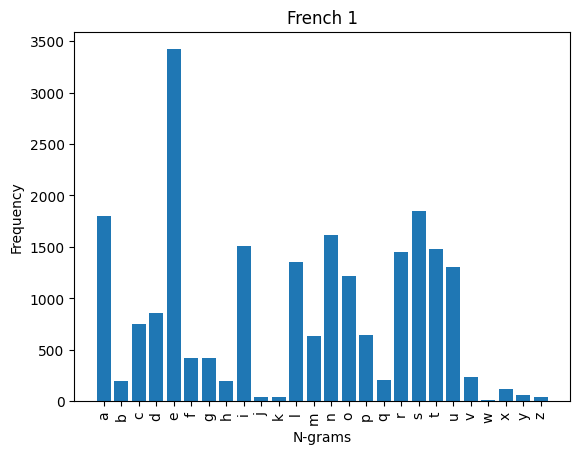

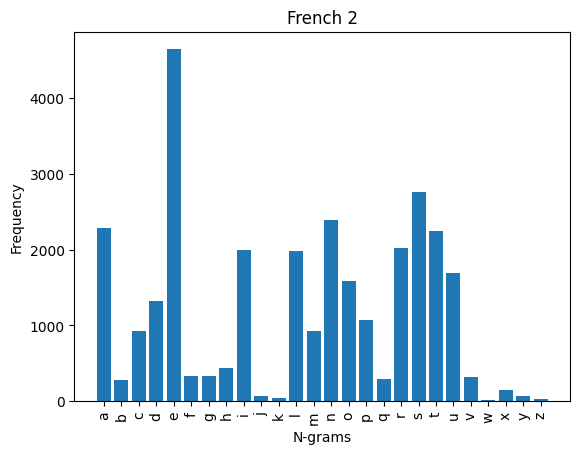

In [ ]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_fr1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

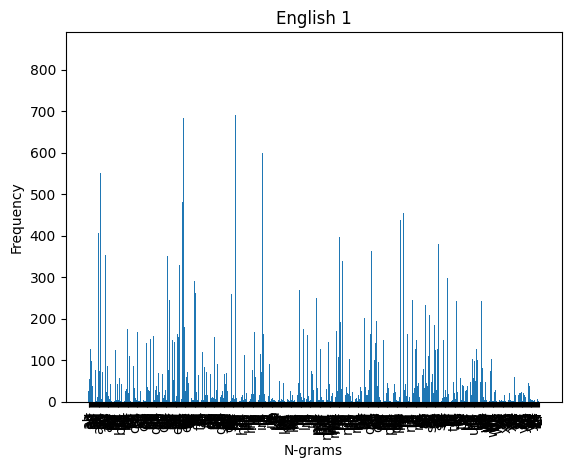

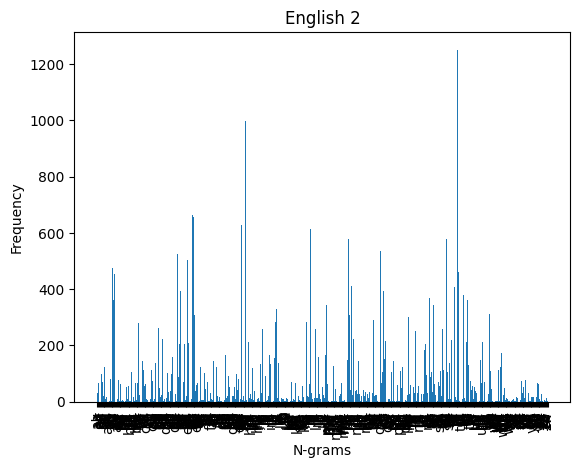

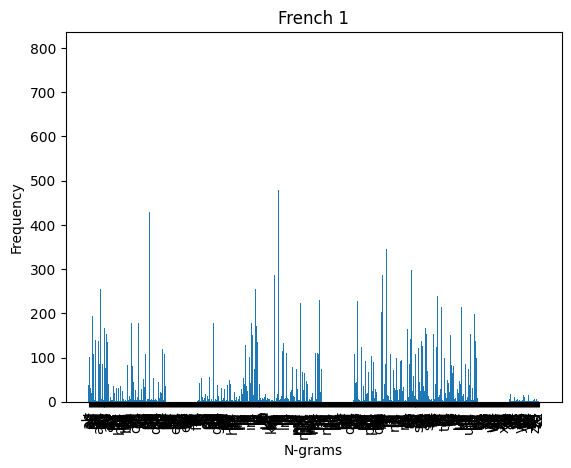

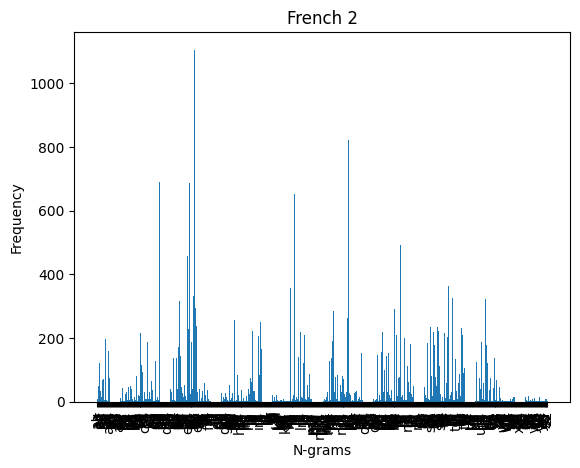

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2))  # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_fr1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [ ]:
def plotbihistogram(ngram):
    freq = np.zeros((26,26))

    for ii in range(26):
        for jj in range(26):
            freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]

    plt.imshow(freq, cmap='jet')
    plt.xticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))
    plt.yticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))
    plt.colorbar()
    plt.show()

    return freq

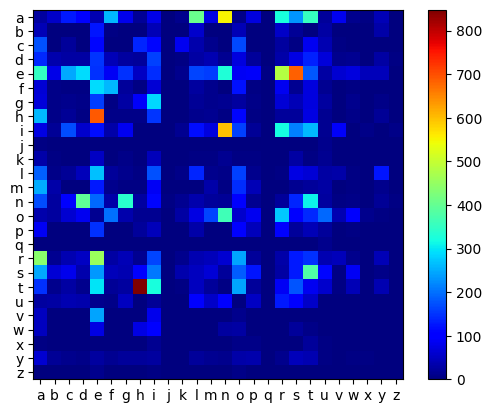

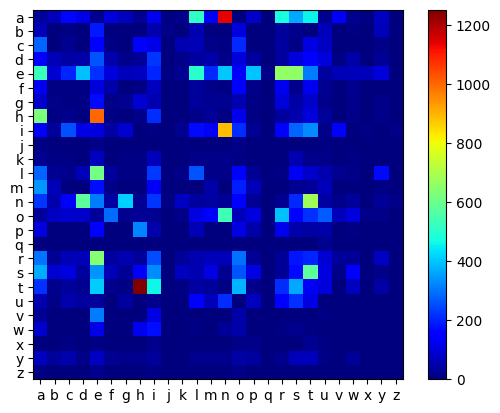

In [ ]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()

bieng2 = plotbihistogram(bigram_eng2)
plt.show()

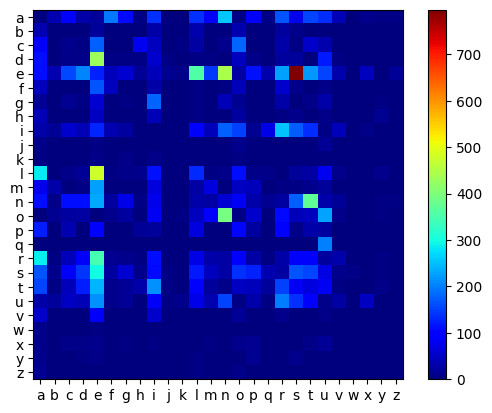

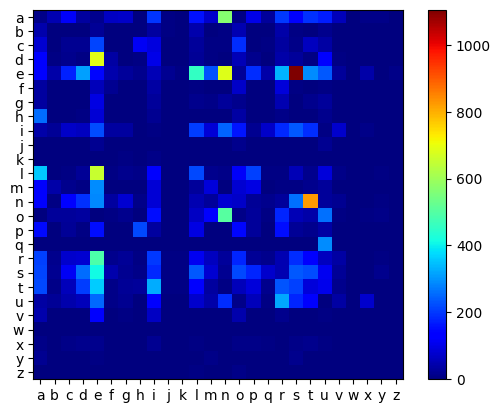

In [ ]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)
plt.show()

Let us look at the top 10 ngrams for each text.

In [ ]:
def ind2tup(ind):
    ind = int(ind)
    i = ind // 26
    j = ind % 26
    return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
    f = bifreq.flatten()
    arg = np.argsort(-f)
    for ii in range(n):
        print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [ ]:
datasets = [
    ("English 1", bieng1),
    ("English 2", bieng2),
    ("French 1", bifr1),
    ("French 2", bifr2)
]

for name, data in datasets:
    print(f"\n{name}:")
    ShowTopN(data, 10)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 796.0
('l', 'e') : 478.0
('e', 'n') : 444.0
('d', 'e') : 430.0
('o', 'n') : 392.0
('n', 't') : 372.0
('e', 'l') : 355.0
('r', 'e') : 346.0
('s', 'e') : 298.0
('r', 'a') : 287.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

**Taking English and Spanish as two different languages**

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=a25d80e3d83e0fb24a859ee56df6da036b83c9ed6743e97263ac2cb86df7019f
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


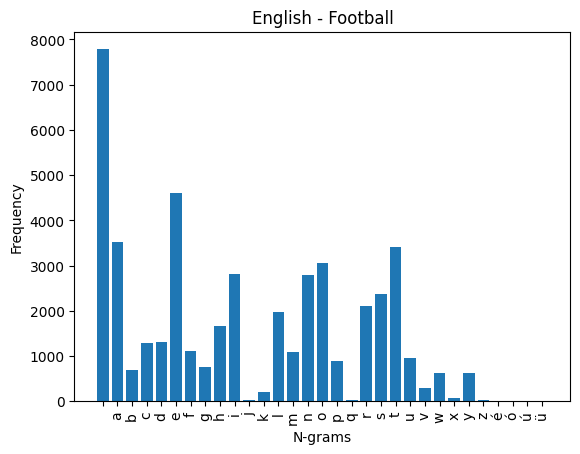

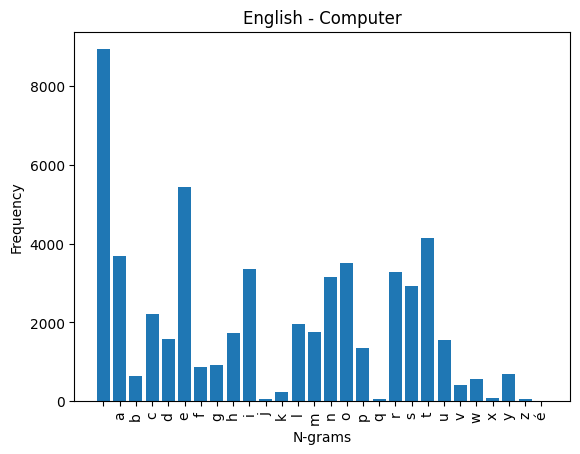

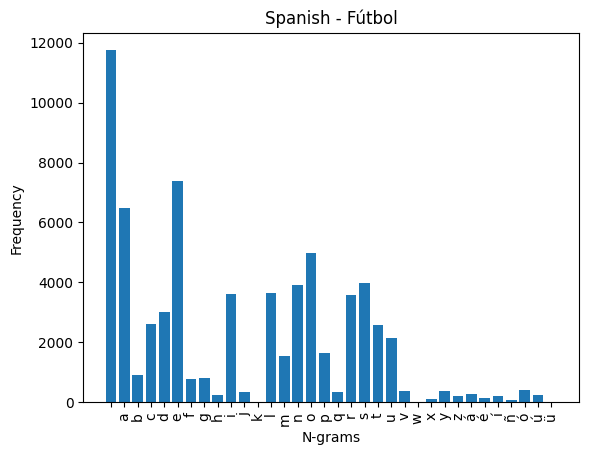

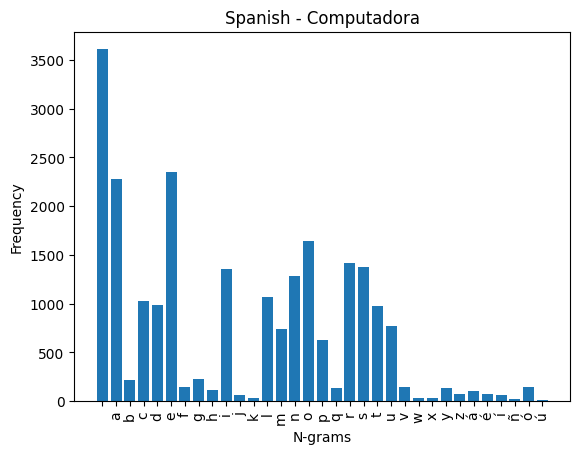

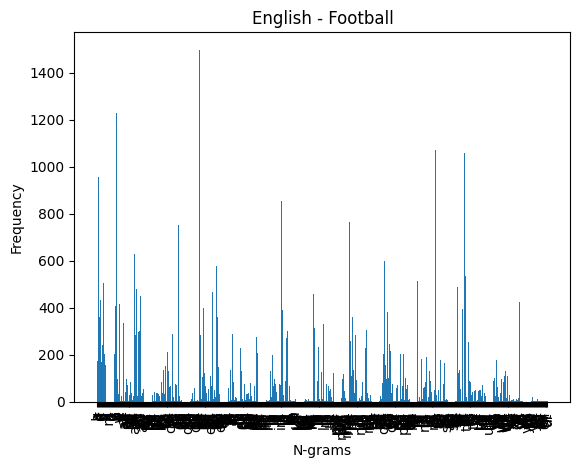

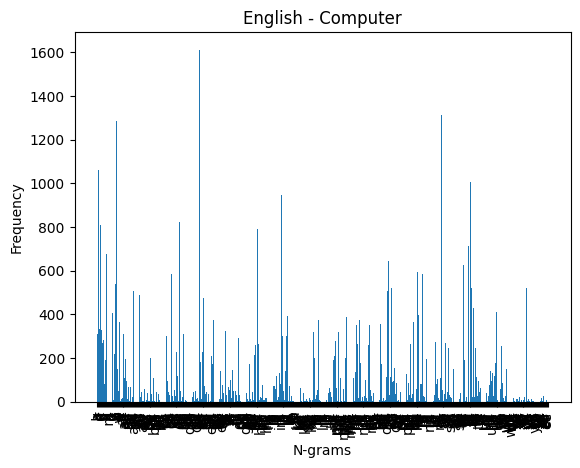

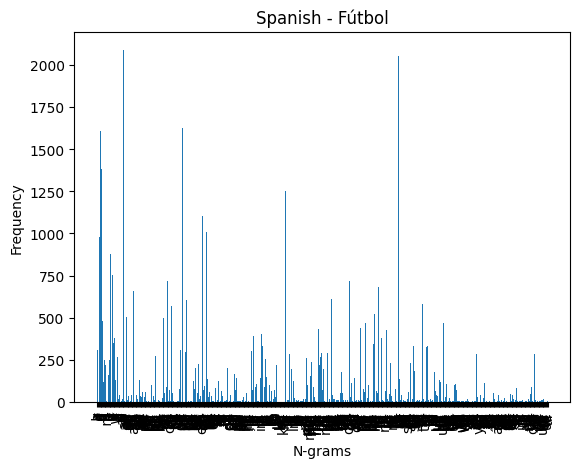

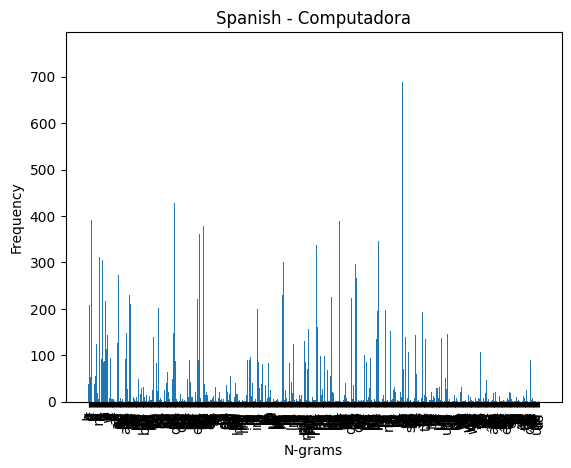

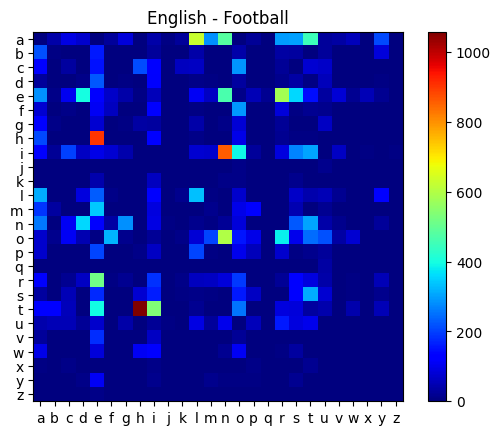

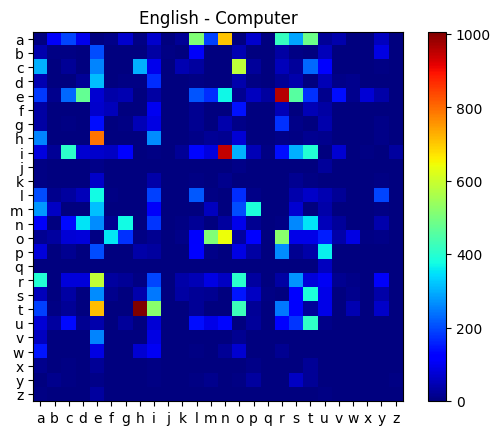

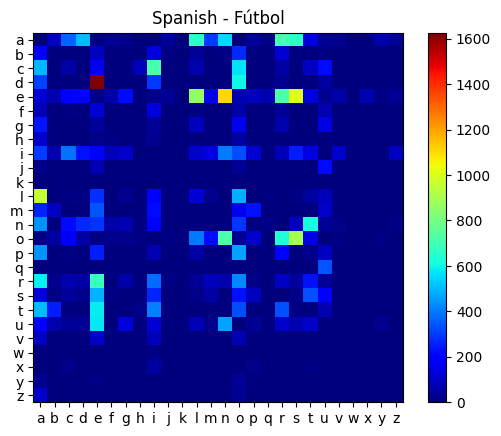

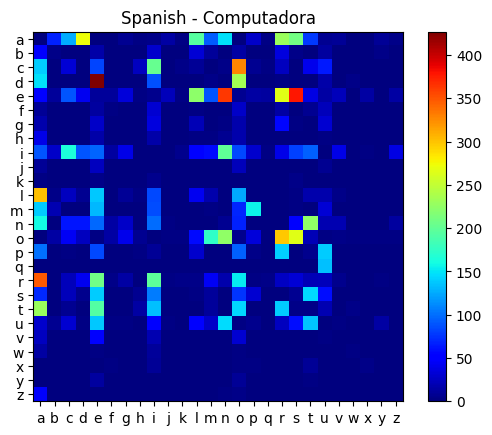


English Football:
('t', 'h') : 1058.0
('h', 'e') : 905.0
('i', 'n') : 856.0
('a', 'l') : 627.0
('o', 'n') : 597.0
('e', 'r') : 579.0
('t', 'i') : 535.0
('r', 'e') : 515.0
('a', 'n') : 480.0
('e', 'n') : 466.0

English Computer:
('t', 'h') : 1006.0
('e', 'r') : 958.0
('i', 'n') : 946.0
('h', 'e') : 793.0
('t', 'e') : 715.0
('a', 'n') : 705.0
('o', 'n') : 644.0
('r', 'e') : 587.0
('c', 'o') : 584.0
('t', 'i') : 522.0

Spanish Fútbol:
('d', 'e') : 1626.0
('e', 'n') : 1106.0
('e', 's') : 1008.0
('l', 'a') : 958.0
('o', 's') : 896.0
('e', 'l') : 857.0
('o', 'n') : 719.0
('e', 'r') : 718.0
('c', 'i') : 716.0
('a', 'r') : 711.0

Spanish Computadora:
('d', 'e') : 427.0
('e', 's') : 378.0
('e', 'n') : 362.0
('r', 'a') : 347.0
('c', 'o') : 328.0
('l', 'a') : 301.0
('o', 'r') : 297.0
('a', 'd') : 272.0
('e', 'r') : 266.0
('o', 's') : 266.0


In [ ]:
# Install & import libraries
!pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re


# ---------------- GET WIKIPEDIA TEXT ----------------

topic1 = "Association football"
topic2 = "Computer"

# English pages
wikipedia.set_lang('en')
eng1 = wikipedia.page(topic1, auto_suggest=False).content
eng2 = wikipedia.page(topic2, auto_suggest=False).content

# Spanish pages
wikipedia.set_lang('es')
sp1 = wikipedia.page("Fútbol", auto_suggest=False).content
sp2 = wikipedia.page("Computadora", auto_suggest=False).content


# ---------------- TEXT CLEANING ----------------

def cleanup(text):
    text = text.lower()
    text = re.sub('[^a-záéíóúñü ]+', '', text)
    return text


# ---------------- HELPER FUNCTIONS ----------------

def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st


def key2string(keys):
    return [tuple2string(i) for i in keys]


def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)
    zipped_sorted = sorted(combined, key=lambda x: x[0])

    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)
    plt.xticks(rotation=90)
    plt.xlabel("N-grams")
    plt.ylabel("Frequency")


# ---------------- BIGRAM HEATMAP ----------------

def plotbihistogram(ngram):
    freq = np.zeros((26,26))

    for ii in range(26):
        for jj in range(26):
            freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]

    plt.imshow(freq, cmap='jet')
    plt.xticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))
    plt.yticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))
    plt.colorbar()

    return freq


# ---------------- TOP BIGRAMS ----------------

def ind2tup(ind):
    ind = int(ind)
    i = ind // 26
    j = ind % 26
    return (chr(ord('a')+i), chr(ord('a')+j))


def ShowTopN(bifreq, n=10):
    f = bifreq.flatten()
    arg = np.argsort(-f)

    for ii in range(n):
        print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')


# ---------------- CLEAN TEXT ----------------

eng1 = cleanup(eng1)
eng2 = cleanup(eng2)

sp1 = cleanup(sp1)
sp2 = cleanup(sp2)


# ---------------- UNIGRAM HISTOGRAMS ----------------

unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English - Football')
plt.show()

unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English - Computer')
plt.show()

unigram_sp1 = Counter(ngrams(sp1,1))
plothistogram(unigram_sp1)
plt.title('Spanish - Fútbol')
plt.show()

unigram_sp2 = Counter(ngrams(sp2,1))
plothistogram(unigram_sp2)
plt.title('Spanish - Computadora')
plt.show()


# ---------------- BIGRAM HISTOGRAMS ----------------

bigram_eng1 = Counter(ngrams(eng1,2))
plothistogram(bigram_eng1)
plt.title('English - Football')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English - Computer')
plt.show()

bigram_sp1 = Counter(ngrams(sp1,2))
plothistogram(bigram_sp1)
plt.title('Spanish - Fútbol')
plt.show()

bigram_sp2 = Counter(ngrams(sp2,2))
plothistogram(bigram_sp2)
plt.title('Spanish - Computadora')
plt.show()


# ---------------- BIGRAM HEATMAPS ----------------

bieng1 = plotbihistogram(bigram_eng1)
plt.title('English - Football')
plt.show()

bieng2 = plotbihistogram(bigram_eng2)
plt.title('English - Computer')
plt.show()

bisp1 = plotbihistogram(bigram_sp1)
plt.title('Spanish - Fútbol')
plt.show()

bisp2 = plotbihistogram(bigram_sp2)
plt.title('Spanish - Computadora')
plt.show()


# ---------------- TOP BIGRAMS ----------------

datasets = [
    ("English Football", bieng1),
    ("English Computer", bieng2),
    ("Spanish Fútbol", bisp1),
    ("Spanish Computadora", bisp2)
]

for name, data in datasets:
    print(f"\n{name}:")
    ShowTopN(data,10)

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [ ]:
from tensorflow.keras.datasets import mnist

# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [ ]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

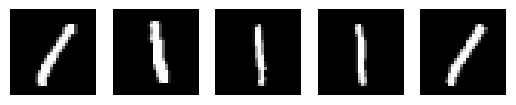

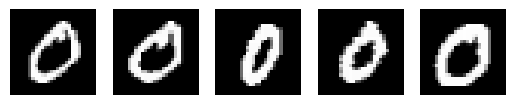

In [ ]:
import matplotlib.pyplot as plt

# show digit 1 images
for ii in range(5):
    plt.subplot(1, 5, ii+1)
    plt.imshow(no1[ii,:,:], cmap='gray')
    plt.axis('off')
plt.show()

# show digit 0 images
for ii in range(5):
    plt.subplot(1, 5, ii+1)
    plt.imshow(no0[ii,:,:], cmap='gray')
    plt.axis('off')
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [ ]:
import numpy as np
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

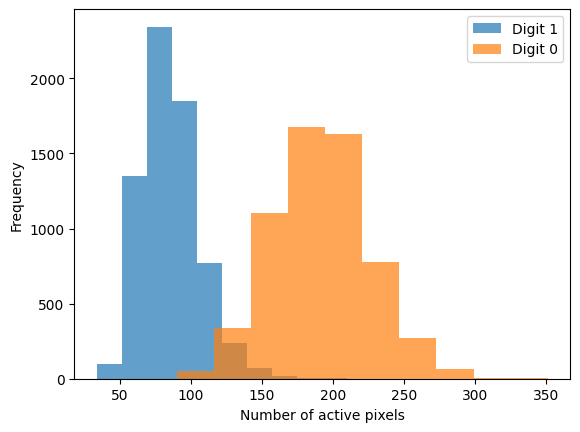

In [ ]:
import matplotlib.pyplot as plt

plt.hist(sum1, alpha=0.7, label='Digit 1')
plt.hist(sum0, alpha=0.7, label='Digit 0')

plt.xlabel("Number of active pixels")
plt.ylabel("Frequency")
plt.legend()

plt.show()

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[0]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

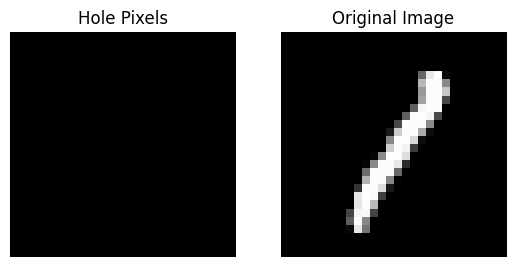

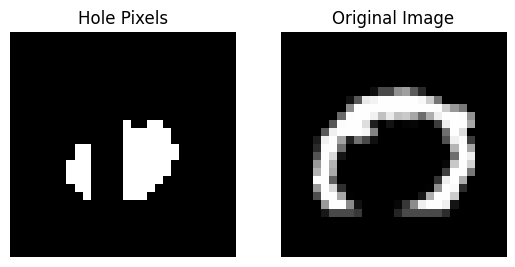

In [ ]:
imgs = [no1[456,:,:], no0[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getHolePixels(img), cmap='gray')
    plt.title("Hole Pixels")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

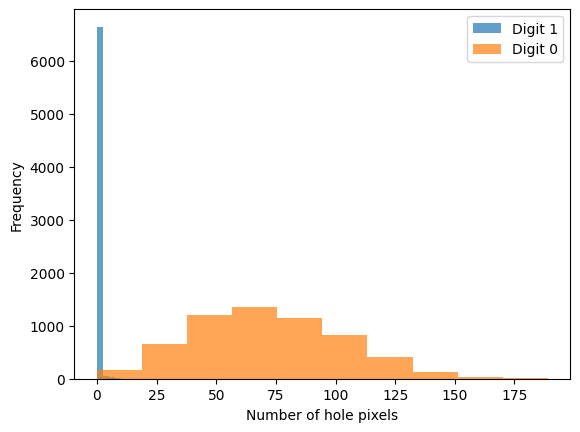

In [ ]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7, label="Digit 1")
plt.hist(hole0, alpha=0.7, label="Digit 0")

plt.xlabel("Number of hole pixels")
plt.ylabel("Frequency")
plt.legend()

plt.show()

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [ ]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[0]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHullPixels(img):
    im1 = cumArray(img)
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)

    hull = im1 & im2 & im3 & im4
    return hull

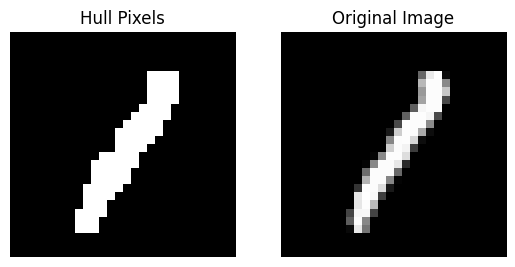

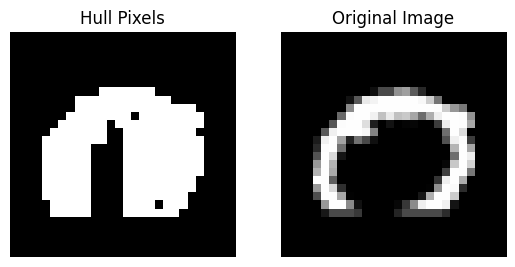

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

imgs = [no1[456,:,:], no0[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getHullPixels(img), cmap='gray')
    plt.title("Hull Pixels")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.show()

Plotting the number of hull pixels versus the digit:

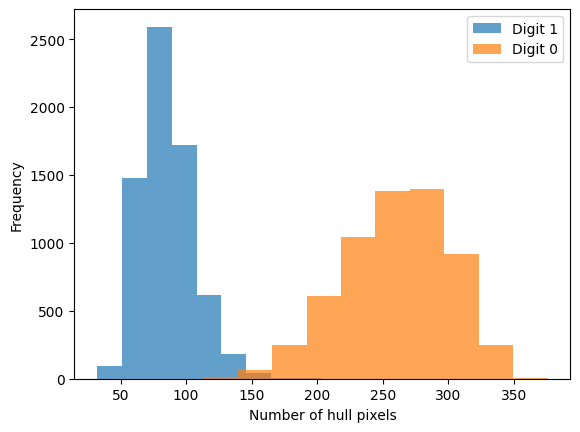

In [ ]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7, label="Digit 1")
plt.hist(hull0, alpha=0.7, label="Digit 0")

plt.xlabel("Number of hull pixels")
plt.ylabel("Frequency")
plt.legend()

plt.show()

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [ ]:
import numpy as np

def minus(a, b):
    return a & ~b

def getBoundaryPixels(img):
    img = img.copy() > 0   # convert to binary image

    rshift = np.roll(img, 1, axis=1)
    lshift = np.roll(img, -1, axis=1)
    ushift = np.roll(img, -1, axis=0)
    dshift = np.roll(img, 1, axis=0)

    boundary = (minus(img, rshift) |
                minus(img, lshift) |
                minus(img, ushift) |
                minus(img, dshift))

    return boundary

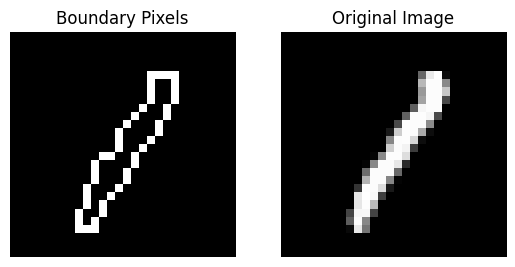

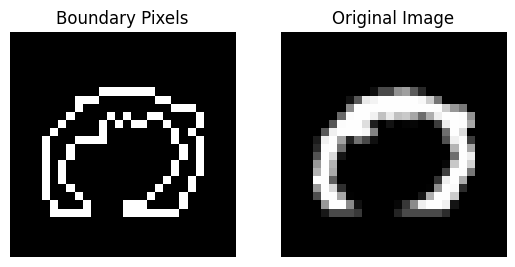

In [ ]:
imgs = [no1[456,:,:], no0[456,:,:]]

for img in imgs:
    plt.subplot(1,2,1)
    plt.imshow(getBoundaryPixels(img), cmap='gray')
    plt.title("Boundary Pixels")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.show()

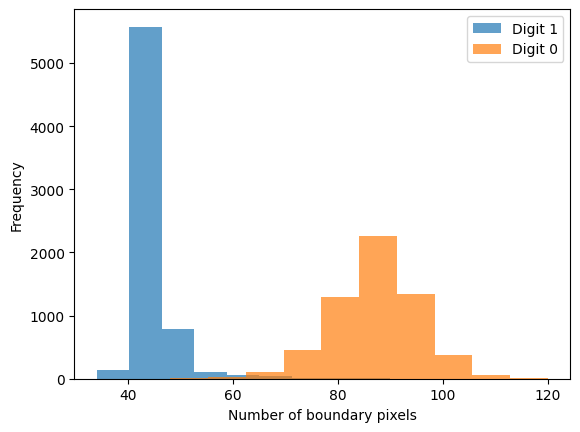

In [ ]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0 = np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7, label="Digit 1")
plt.hist(bound0, alpha=0.7, label="Digit 0")

plt.xlabel("Number of boundary pixels")
plt.ylabel("Frequency")
plt.legend()

plt.show()

What will happen if we plot two features together?

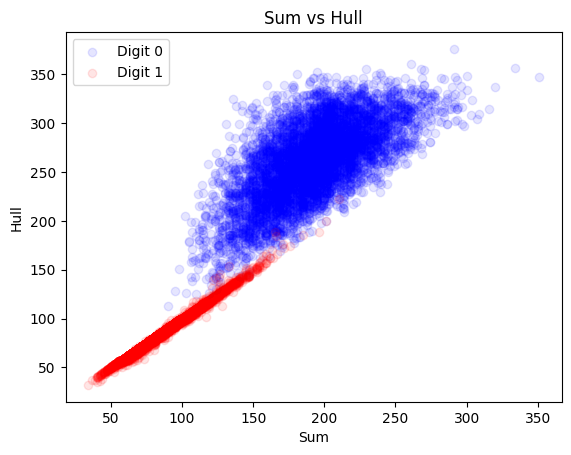

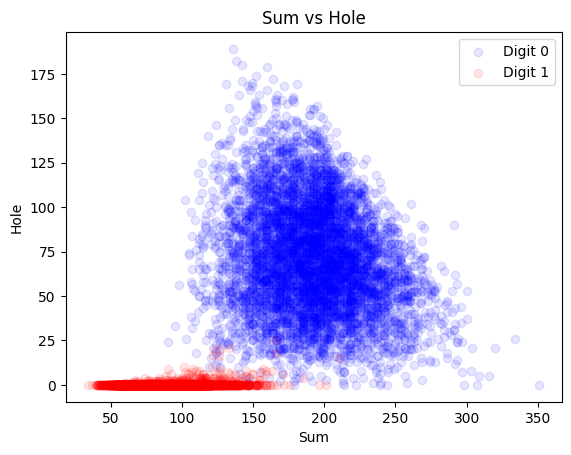

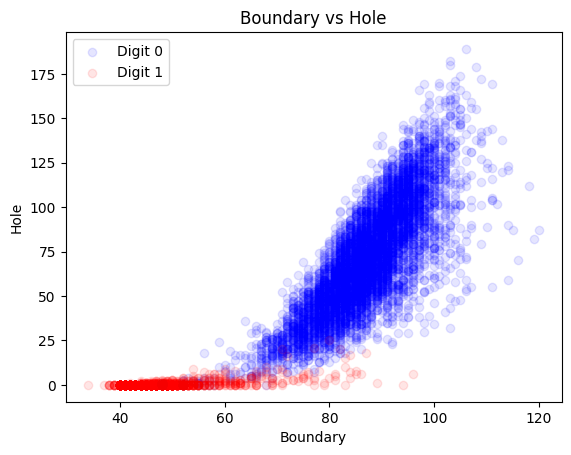

In [ ]:
# Sum vs Hull
plt.scatter(sum0, hull0, alpha=0.1, color='blue')
plt.scatter(sum1, hull1, alpha=0.1, color='red')
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.title('Sum vs Hull')
plt.legend(['Digit 0', 'Digit 1'])
plt.show()

# Sum vs Hole
plt.scatter(sum0, hole0, alpha=0.1, color='blue')
plt.scatter(sum1, hole1, alpha=0.1, color='red')
plt.xlabel('Sum')
plt.ylabel('Hole')
plt.title('Sum vs Hole')
plt.legend(['Digit 0', 'Digit 1'])
plt.show()

# Boundary vs Hole
plt.scatter(bound0, hole0, alpha=0.1, color='blue')
plt.scatter(bound1, hole1, alpha=0.1, color='red')
plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.title('Boundary vs Hole')
plt.legend(['Digit 0', 'Digit 1'])
plt.show()

Now let us try plotting 3 features together.

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np

# Create class labels
cl1 = ['Digit 1'] * len(sum1)
cl0 = ['Digit 0'] * len(sum0)

# Create dataframe combining all features
df = pd.DataFrame(
    list(zip(
        np.concatenate((hole1, hole0)),
        np.concatenate((sum1, sum0)),
        np.concatenate((bound1, bound0)),
        np.concatenate((cl1, cl0))
    )),
    columns=['Hole', 'Sum', 'Boundary', 'Class']
)

# Preview the dataframe
df.head()

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x='Hole',
    y='Sum',
    z='Boundary',
    color='Class',
    opacity=0.3,
    title='3D Visualization of MNIST Features (0 vs 1)'
)

fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?

Q1. Which is the best combination of features?

Ans: The best combination of features is Hole pixels and Sum of pixels.
From the scatter plots and the 3D visualization, digit 1 has almost zero hole pixels while digit 0 has many hole pixels. This creates a clear separation between the two classes.

Q2. How would you test or visualize four or more features?

Ans: When four or more features are present, direct visualization becomes difficult. In such cases we can use pairwise scatter plots, dimensionality reduction techniques such as PCA or t-SNE, or correlation analysis. These methods help understand relationships between multiple features.

Q3. Can you come up with your own features?

Ans: Yes, additional features can be designed from the images. Examples include center of mass of pixels, symmetry of the digit, aspect ratio, stroke thickness, and number of connected components. These features can help distinguish between different handwritten digits.

Q4. Will these features work for different classes other than 0 and 1?

Ans: These features may not work well for other digit classes. For example, digits such as 0, 6, 8, and 9 all contain holes, so the hole feature alone cannot distinguish them. Similarly, other features like pixel sum may overlap across different digits. Therefore, more features or advanced machine learning models may be required to classify all digits accurately.

Q5. What will happen if we take more that two classes at a time?

Ans: If more than two classes are used, the problem becomes a multi-class classification problem. The feature distributions may overlap and simple features may not be sufficient to clearly separate all digits. In such cases, additional features or machine learning models are required to accurately classify the digits.